# Aprendizaje por refuerzo DQN
**Proyecto PAPIME PE104425 "Visualización animada en 3D de Redes Neuronales"**

**Fuentes:**

- [Reinforcement Learning (DQN) Tutorial](https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html)
- [Gymnasium Documentation - Basic Usage](https://gymnasium.farama.org/introduction/basic_usage/)
- [A Complete Guide to Better Jupyter Notebooks Formatting](https://medium.com/@vihasharma1099/a-complete-guide-to-beautify-your-jupyter-notebooks-d49e06fa8b3f)
- [Saving and Loading Models](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)

In [1]:
# Dependencias
#!pip3 install gymnasium[classic_control]

In [2]:
from IPython import display

## Escenario

In [3]:
import gymnasium as gym

In [4]:
import matplotlib
import matplotlib.pyplot as plt

### Ilustremos

**Referencia:** [Gymnasium Documentation - Env](https://gymnasium.farama.org/api/env/#gymnasium.Env.render)

Acciones: ['izquierda', 'derecha']
  Hay 2 acciones posibles codificadas como int64

Observaciones: ['posición del carro', 'velocidad del carro', 'ángulo del poste', 'velocidad angular del poste']
El espacio de obsevaciones contiene (4,) datos de tipo float32
    con límites inferiores [-4.8               -inf -0.41887903        -inf]
    y límites superiores   [4.8               inf 0.41887903        inf]

Estado inicial observado: ['posición del carro', 'velocidad del carro', 'ángulo del poste', 'velocidad angular del poste'] = [ 0.0247361   0.0178433  -0.01514594 -0.01099377]


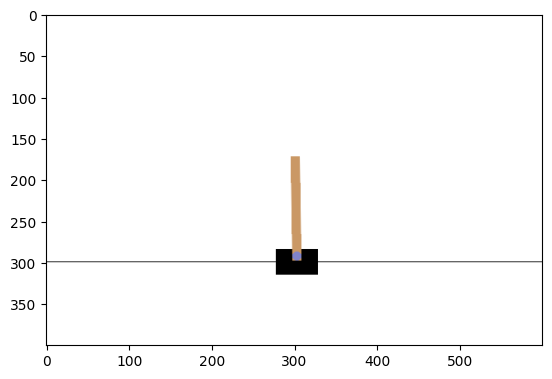

In [5]:
# Crea el ambiente
env = gym.make("CartPole-v1", render_mode="rgb_array")


# Acciones
#  Acciones de dos tipos:
#  0 = mover el carro a la izquierda
#  1 = mover el carro a la derecha
#  dtype('int64')
action_space = env.action_space
action_names = ["izquierda", "derecha"]
print(f"Acciones: {action_names}")
print(f"  Hay {action_space.n} acciones posibles codificadas como {action_space.dtype}")
print()


# Observaciones
observation_space = env.observation_space
observation_names = ["posición del carro", "velocidad del carro", "ángulo del poste", "velocidad angular del poste"]
print(f"Observaciones: {observation_names}")
print(f"""El espacio de obsevaciones contiene {observation_space.shape} datos de tipo {observation_space.dtype}
    con límites inferiores {observation_space.low}
    y límites superiores   {observation_space.high}""")
print()

# Reinicia el ambiente para inciar un episodio
state, info = env.reset()
print(f"Estado inicial observado: {observation_names} = {state}")
image = env.render()
plt.imshow(image)
env.close()

### Una escena completa

In [6]:
# Crea el ambiente
env = gym.make("CartPole-v1", render_mode="human")

# Reinicia el ambiente para inciar un episodio
state, info = env.reset()

print("Episodio 1")
print(f"    Acción   Estado: {observation_names}   Recompensa")

episode_over = False
total_reward = 0
paso = 0

while not episode_over:

    action = env.action_space.sample()  # Elige una acción al azar

    # Ejecuta la acción y ve qué pasa
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{paso:3d}    {action}                 {observation}                                                 {reward}")

    # recompensa: +1 si el poste aún está vertical
    # terminated: True si el poste se cae (el agente falla)
    # truncated: True si llegamos al final de episodio (500 pasos)

    total_reward += reward
    paso += 1
    episode_over = terminated or truncated

print(f"Fin del episodio.  Recompensa total obtenida: {total_reward}")
plt.pause(1)  # Esperamos un poco para observar el estado final
env.close()

Episodio 1
    Acción   Estado: ['posición del carro', 'velocidad del carro', 'ángulo del poste', 'velocidad angular del poste']   Recompensa
  0    0                 [-1.4938808e-04 -1.4596531e-01 -5.1503344e-03  3.0057973e-01]                                                 1.0
  1    0                 [-0.00306869 -0.34101346  0.00086126  0.5916339 ]                                                 1.0
  2    1                 [-0.00988896 -0.14590359  0.01269394  0.2992224 ]                                                 1.0
  3    1                 [-0.01280704  0.04903514  0.01867839  0.01056979]                                                 1.0
  4    0                 [-0.01182633 -0.14634964  0.01888978  0.30908695]                                                 1.0
  5    1                 [-0.01475333  0.04849815  0.02507152  0.02242069]                                                 1.0
  6    1                 [-0.01378336  0.24325174  0.02551994 -0.26224765]          

## Apendizaje por refuerzo Q

### Definiciones

### Recompensa descontada acumulada

Es la **recompensa total**, es decir, la suma de todas las recompensas que recibirá el agente a partir de realizar su acción en el estado en que se encuentra, descontando la contribución de recompensas que recibirá muy a futuro.

\begin{align}
 V^{\pi}(s_t) &\equiv r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + ... \equiv \sum_{i=0}^{\infty} \gamma^i r_{t+i}
\end{align}
con $0 \leq \gamma < 1$.

Dado que esta recompensa dependerá de las acciones que eliga, queremos encontrar una política $\pi^*$ que elija la mejor acción para cada estado, de modo que se maximice esa recompensa.

<center><img src="figuras/refuerzo_v.png" width="500" /></center>

Si la política elegida no es óptima, los valores de $V$ cambian:

<center><img src="figuras/refuerzo_vnooptimo.png"  width="250"/></center>

**¿Cómo obtener la política óptima?** Para ello, estudiaremos una función más general, que no sólo considera la acción elegida, sino todas las acciones que el agente tiene a su disponibilidad al momento de tomar su decisión.  Después de ello, esta función asumirá que se sigue una cierta política $\pi$, que habrá que especificar.  De este modo se obtiene la llamada _Ecuación de Bellman_:

\begin{align}
 Q^{\pi}(s, a) &\equiv r + \gamma Q^{\pi}(s', \pi(s'))
\end{align}

<center><img src="figuras/refuerzo_q.png"  width="250"/></center>

Buscamos entonces las acciones que maximicen la recompensa calculada por $Q$:

\begin{align}
 \pi^*(s) = \arg\!\max_a \ Q^*(s,a )
\end{align}

### Función de error

Para aproximarnos a la política óptima utilizaremos como estimación del error la diferencia temporal $\delta$, que es la diferencia entre los dos lados de la ecuación de Bellman, provocada por no tener el valor exacto de $Q$ y realizar la estimación de elegir, para el estado siguiente, la acción que maximice el valor actualmente conocido de $Q$:
\begin{align}
 \delta = Q(s, a) - (r + \gamma \max_a' Q(s', a))
\end{align}

Para obtener un error positivo, que no se dispare por la presencia de valores atípicos, se introduce este valor en la llamada _pérdida de Huber_, calculada sobre un lote de transiciones $B$:
\begin{align}
 \mathcal{L} &= \frac{1}{|B|}\sum_{(s, a, s', r) \ \in \ B} \mathcal{L}(\delta)
\end{align}
<div class="math">
\[\text{donde} \quad \mathcal{L}(\delta) = \begin{cases}
  \frac{1}{2}{\delta^2}  & \text{si } |\delta| \le 1, \\
  |\delta| - \frac{1}{2} & \text{de otro modo.}
\end{cases}\]</div>

## Implementación

### Memoria: grabado de los eventos

Por cada episodio en el ambiente virtual, se guardarán:
* El estado en el que estaba el ambiente
* La acción que se tomó
* El estado al que se transitó
* La recompensa recibida en ese momento

Para ello se usarán los objetos siguientes:

In [7]:
# https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

from collections import namedtuple, deque

# Mapea el (estado, acción) a (estado sucesor, recompensa) observados
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    """
    Buffer cíclico de tamaño restringido que almacena las transiciones observadas más
    recientemente.
    """

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """ Guarda los datos de una transición. """
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """
        Selecciona un lote de transiciones aleatorias. 
        Útil para entrenar la red.
        """
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### Red-Q

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DQN(nn.Module):
    """
    Dada la diferencia entre el estado actual y el anterior, predice
    la ganacia que daría, en el siguiente paso, realizar cada una de las
    acciones posibles Q(s, izquierda) y Q(s, derecha)
    """

    def __init__(self, n_observations, n_actions):
        """
        n_observations: diferencia entre el estado actual y el anterior
        n_actions: hay dos acciones, moverse a la izquierda o a la derecha
        """
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        """
        x: un elemento o lote
        returns: tensor([[left0exp,right0exp]...])
        """
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

### Herramientas auxiliares para el entrenamiento

#### Exploración vs explotación

¿Cómo elegirá el agente que acción realizar mientras se está entrenando?  Una estrategia simple es:

1. **Explotación:** Utiliza la acción que obtendrá la mayor recompensa según nuestra aproximación actual de $Q(s,a)$
2. **Exploración:** Elige una acción al azar

<div class="alert alert-info">
NOTA: El paso 2 se podría mejorar estimando la acción que produzca el mejor aprendizaje ¿cómo decidirías qué tan buena es la estimación actual de $Q$ para cada acción?
</div>

In [9]:
import random
import math

class ActionSelector:
    """
    Selecciona la acción.
    La estrategia se modifica dependiendo del número de pasos desde que
    inició el entrenamiento.  La probabilidad de seleccionar una acción al
    azar decae exponencialmente de EPS_START a EPS_END según la tasa EPS_DECAY.
    """
    def __init__(self, EPS_START, EPS_END, EPS_DECAY):
        self.EPS_END = EPS_END
        self.EPS_START = EPS_START
        self.EPS_DECAY = EPS_DECAY
        self.steps_done = 0

    def select_action(self, state):
        sample = random.random()

        # Probabilidad de elegir una acción al azar
        eps_threshold = self.EPS_END + (self.EPS_START - self.EPS_END) * \
            math.exp(-1. * self.steps_done / self.EPS_DECAY)
        
        self.steps_done += 1
        if sample > eps_threshold:
            # Selecciona la mejor acción conocida al momento
            with torch.no_grad():
                # t.max(1) devuelve el valor más grande en la columna para cada renglón.
                # la 2a columna en el resultado devuelto por max es el índice donde se
                # encontraba ese valor.  Elegimos la acción que corresponde a ese valor.
                return policy_net(state).max(1).indices.view(1, 1)
        else:
            # Selecciona una acción al azar de entre todas las disponibles para el agente
            return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

#### Monitoreo

Entre más avance el entrenamiento, el agente debiera ser capaz de completar secuencias más largas sin fallar.

In [10]:
def plot_durations(episode_durations, show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Resultado')
    else:
        plt.clf()
        plt.title('Entrenando...')
    plt.xlabel('Episodio')
    plt.ylabel('Duración')
    plt.plot(durations_t.numpy(), label="Duraciones")
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy(), label="Duraciones promedio")
    plt.legend()

    plt.pause(0.001)  # pause a bit so that plots are updated

    if not show_result:
        display.display(plt.gcf())
        display.clear_output(wait=True)
    else:
        display.display(plt.gcf())

### Entrenamiento

#### Optimización

Un sólo paso de optimización:
1. Muestrear un lote
2. Calcular $Q(s_t, a_t)$ y aproximar $V(s_{t+1})=\max_a Q(s_{t+1}, a)$ para estimar la pérdida
3. Por definición $V(s)=0$ si $s$ es un **estado terminal**.

Técnica auxiliar:
1. Entrenar dos redes neuronales:
    1. Una red Q para adquirir la política de acción
    2. Otra red Q, llamda _red objetivo_ para estimar $V(s_{t+1})$, valor necesario para actualizar la red original.  Esto añade estabilidad al algoritmo de optimización.
2. Actualizar la red objetivo mediante una [optmización suave](https://arxiv.org/pdf/1509.02971)

In [11]:
def optimize_model(memory, policy_net, target_net):
    # .-. Obtener lote de entrenamiento -.-
    
    if len(memory) < BATCH_SIZE:
        # No hay suficiente experiencia para comenzar el aprendizaje
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transponer el lote (ver https://stackoverflow.com/a/19343/3343043 para
    # una explicación detallada). Esto convierte el arreglo de Transitions en una
    # Transition de arreglos de lotes.  Es cómo para acceder todos los estados, estados
    # siguientes, acciones y recompensas del lote mediante la llamada a un solo atributo.
    batch = Transition(*zip(*transitions))

    # .-. OJO con los estados finales, ahí termina el juego -.-

    # Computa una máscara de estados no-finales y concatena los elementos del lote
    # (un estado final sería aquel después del cual termina la simulación)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)),
                                  device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    

    # Calcular Q(s_t, a) - el modelo calcula Q(s_t), de ahí seleccionamos las
    # columnas de las acciones que realizó.  Estas son las acciones que se habrían
    # realizado para cada estado en el lote según la policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    
    # .-. Calcular V(s_{t+1}) para todos los estados siguientes. -.-
    
    # Se utiliza la red objetivo del paso anterior para calcular las recompensas
    # acumuladas esperadas V(s_{t+1}) para las acciones que se tomarían después de los
    # estados siguientes no finales non_final_next_states; a partir de la estimación de Q
    # en el paso anterior.
    # Para ello se seleccionan los valores más altos de Q para cada estado con max(1).values,
    # suponiendo que se tomaría la acción óptima según los datos en ese tiempo.
    # Esto se mezcla utilizando la máscara, para que tengamos ya sea el valor del estado esperado
    # o 0 si el estado al que se transita es final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Calcular los valores esperados de Q
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # .-. Calcular la pérdida de Huber -.-
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # .-. Optimizar el modelo -.-
    optimizer.zero_grad()
    loss.backward()
    # Truncar el gradien en-el-lugar para evitar explosciones
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

#### Parámetros y entrenamiento

In [12]:
import torch.optim as optim

# .-. Lotes de entrenamiento: -.-
## BATCH_SIZE número de transiciones a muestrear de la memoria
## GAMMA factor de penalización para recompensas tardías

# .-. Selección de acción siguiente -.-
# EPS_START valor incial de epsilon
# EPS_END valor final de epsilon
# EPS_DECAY tasa de decaimiento exponencial para epsilon, un valor más grande implica un decaimiento más lento

# .-. Algoritmo de optimización
# TAU tasa de actualización de la red objetivo
# LR  tasa de aprendizaje del optimizador ``AdamW``

BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005
LR = 3e-4


# .-. Ambiente -.-
env = gym.make("CartPole-v1")

# Obtener el número de acciones posibles desde el espacio de acciones del gimnasio
n_actions = env.action_space.n
# Obtener el número de variables en la representación del estado
state, info = env.reset()
n_observations = len(state)


# .-. GPU ó CPU

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print("Por realizar entrenamiento con", device)

# To ensure reproducibility during training, you can fix the random seeds
# by uncommenting the lines below. This makes the results consistent across
# runs, which is helpful for debugging or comparing different approaches.
#
# That said, allowing randomness can be beneficial in practice, as it lets
# the model explore different training trajectories.


# seed = 42
# random.seed(seed)
# torch.manual_seed(seed)
# env.reset(seed=seed)
# env.action_space.seed(seed)
# env.observation_space.seed(seed)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed)


# .-. Creación de las redes -.-
policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

action_selector = ActionSelector(EPS_START, EPS_END, EPS_DECAY)

Por realizar entrenamiento con cuda


#### Entrenamiento

In [13]:
from itertools import count

def train():
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        num_episodes = 600
    else:
        num_episodes = 50

    episode_durations = []
    for i_episode in range(num_episodes):
        # Initialize the environment and get its state
        state, info = env.reset()
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        for t in count():
            action = action_selector.select_action(state)
            observation, reward, terminated, truncated, _ = env.step(action.item())
            reward = torch.tensor([reward], device=device)
            done = terminated or truncated
    
            if terminated:
                next_state = None
            else:
                next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    
            # Store the transition in memory
            memory.push(state, action, next_state, reward)
    
            # Move to the next state
            state = next_state
    
            # Perform one step of the optimization (on the policy network)
            optimize_model(memory, policy_net, target_net)
    
            # Soft update of the target network's weights
            # θ′ ← τ θ + (1 −τ )θ′
            target_net_state_dict = target_net.state_dict()
            policy_net_state_dict = policy_net.state_dict()
            for key in policy_net_state_dict:
                target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
            target_net.load_state_dict(target_net_state_dict)
    
            if done:
                episode_durations.append(t + 1)
                plot_durations(episode_durations)
                break
    
    print('Complete')
    plot_durations(episode_durations, show_result=True)
    plt.ioff()
    plt.show()

Complete


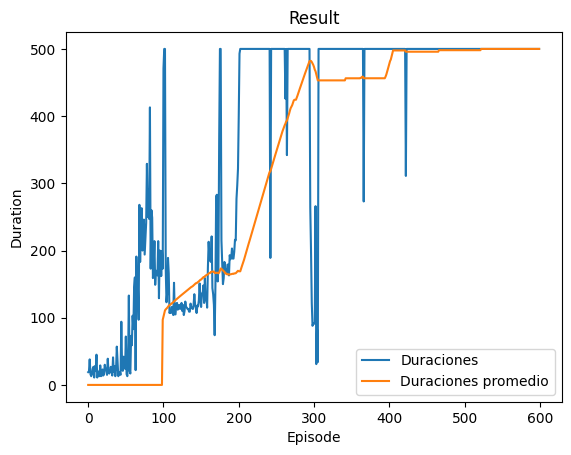

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [14]:
train()

In [ ]:
torch.save(policy_net.state_dict(), 'data/policy_weights.pth'))
torch.save({
            'polic_state_dic': policy_net.state_dict(),
            'target_state_dict': modelB.state_dict(),
            }, 'data/dqn.tch')

<div class="alert alert-success">
    <b>Tarea:</b>
    Visualiza una animación donde el carro se mueva utilizando la acción recomendada por tu red recién entrenada.
</div>